##### 실행 환경 설정

In [1]:
try:
    # Google Drive를 Colab에 마운트
    from google.colab import drive
    drive.mount('/google_drive')

    # 작업 경로 설정
    WORK_DIR = "/google_drive/Othercomputers/'내 컴퓨터'/sec08"
    print("\n[작업 폴더 목록]")
    %cd {WORK_DIR}
    !ls

    # 데이터셋 경로 설정
    DATASET_PATH = "/datasets/construction-ppe"
    import os
    if not os.path.exists(DATASET_PATH):
        !mkdir -p "/datasets/construction-ppe"
        # construction-ppe.zip 다운로드
        import urllib
        urllib.request.urlretrieve(
            "https://github.com/ultralytics/assets/releases/download/v0.0.0/construction-ppe.zip",
            "/datasets/construction-ppe.zip"
        )
        # construction-ppe.zip 압축 해제
        !unzip -qn "/datasets/construction-ppe.zip" -d "/datasets/construction-ppe"
        # construction-ppe.zip 파일 삭제
        !rm "/datasets/construction-ppe.zip"
    print("\n[데이터셋 폴더 목록]")
    print(DATASET_PATH)
    !ls {DATASET_PATH}
    print(DATASET_PATH + "/images")
    !ls {DATASET_PATH}/images
    print(DATASET_PATH + "/labels")
    !ls {DATASET_PATH}/labels
    print()

    # data.yaml의 path를 절대 경로(앞에 / 붙임)로 변경
    import yaml
    yaml_path = "/datasets/construction-ppe/data.yaml"
    with open(yaml_path, 'r') as f:
        cfg = yaml.safe_load(f)
    cfg['path'] = '/datasets/construction-ppe'
    with open(yaml_path, 'w') as f:
        yaml.dump(cfg, f, allow_unicode=True, sort_keys=False)

    # 한글 폰트 설치
    import matplotlib.pyplot as plt
    import matplotlib.font_manager as fm
    !apt-get -qq install fonts-nanum
    fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
    plt.rcParams['font.family'] = 'NanumGothic'
    # 마이너스 기호 깨짐 방지
    plt.rcParams['axes.unicode_minus'] = False
except Exception:
    # 데이터셋 경로 설정
    DATASET_PATH = "../datasets/construction-ppe"

    # 로컬 dataset 폴더 접근 확인
    import os
    print("\n[데이터셋 폴더 목록]")
    print(f"{DATASET_PATH}")
    for dir in os.listdir(DATASET_PATH):
        print(dir, end='  ')

    # 한글 폰트 설정
    import matplotlib.pyplot as plt
    plt.rcParams['font.family'] = 'Malgun Gothic'
    # 마이너스 기호 깨짐 방지
    plt.rcParams['axes.unicode_minus'] = False

Mounted at /google_drive

[작업 폴더 목록]
/google_drive/Othercomputers/내 컴퓨터/sec08
01_object_detection_yolo_info.ipynb
02_object_detection_yolo_dataset.ipynb
03_object_detection_yolo_train.ipynb
04_object_detection_yolo_visualization.ipynb
05_segmentation_yolo_info.ipynb
06_segmentation_yolo_dataset.ipynb
07_segmentation_yolo_train.ipynb
08_segmentation_yolo_visualization.ipynb
detect
runs
yolo11n.pt
yolo26n.pt

[데이터셋 폴더 목록]
/datasets/construction-ppe
data.yaml  images  labels  LICENSE
/datasets/construction-ppe/images
test  train  val
/datasets/construction-ppe/labels
test  train  val

Selecting previously unselected package fonts-nanum.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


##### 임포트

In [2]:
%%capture
!pip install -U ultralytics
from ultralytics import YOLO
import torch
from IPython.display import Image, display

##### Device 설정

In [3]:
# 디바이스 설정: GPU 사용 가능하면 cuda, 아니면 cpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {device}")

사용 디바이스: cuda


##### 모델 로드

In [4]:
# 사전 학습 가중치로 모델 로드
model = YOLO("yolo26n")
print(model.info())

(260, 2572280, 0, 6.1192448)


##### 파인튜닝하기

In [5]:
train_results = model.train(
    data=f"{DATASET_PATH}/data.yaml",           # data.yaml 경로
    epochs=100,                                 # 훈련 에포크 수
    imgsz=640,                                  # 입력 이미지 크기(기본 640)
    batch=-1,                                   # -1: Ultralytics가 GPU VRAM의 60% 기준으로 자동 계산
    lr0=0.001,                                  # 초기 학습률 (기본값 0.01의 1/10)
    patience=10,                                # Early Stopping: 개선 없으면 중단
    device='',                                  # GPU가 있으면 사용 없으면 CPU
    workers=2,                                  # 데이터 로더 워커 수(코랩일 경우 2 권장)
    name="03",                                  # 결과가 저장될 폴더 이름
    exist_ok=True                               # 결과 저장 폴더를 덮어쓰기 여부, 기본값 False는 끝에 번호를 붙임
)

train: Scanning /datasets/construction-ppe/labels/train... 1132 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1132/1132 1.5Kit/s 0.8s
train: Scanning /datasets/construction-ppe/labels/train.cache... 1132 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1132/1132 339.1Mit/s 0.0s
val: Scanning /datasets/construction-ppe/labels/val... 143 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 143/143 1.4Kit/s 0.1s
      1/100      11.8G      1.954      4.831    0.01681        292        640: 100% ━━━━━━━━━━━━ 19/19 1.0s/it 19.9s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 3.6s/it 7.2s
      2/100      13.3G      1.695      4.423    0.01465        221        640: 100% ━━━━━━━━━━━━ 19/19 3.4it/s 5.6s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 4.4it/s 0.5s
      3/100      13.3G      1.708      3.609    0.01491        221        640: 100% ━━━━━━━━━━━━

학습 결과 확인

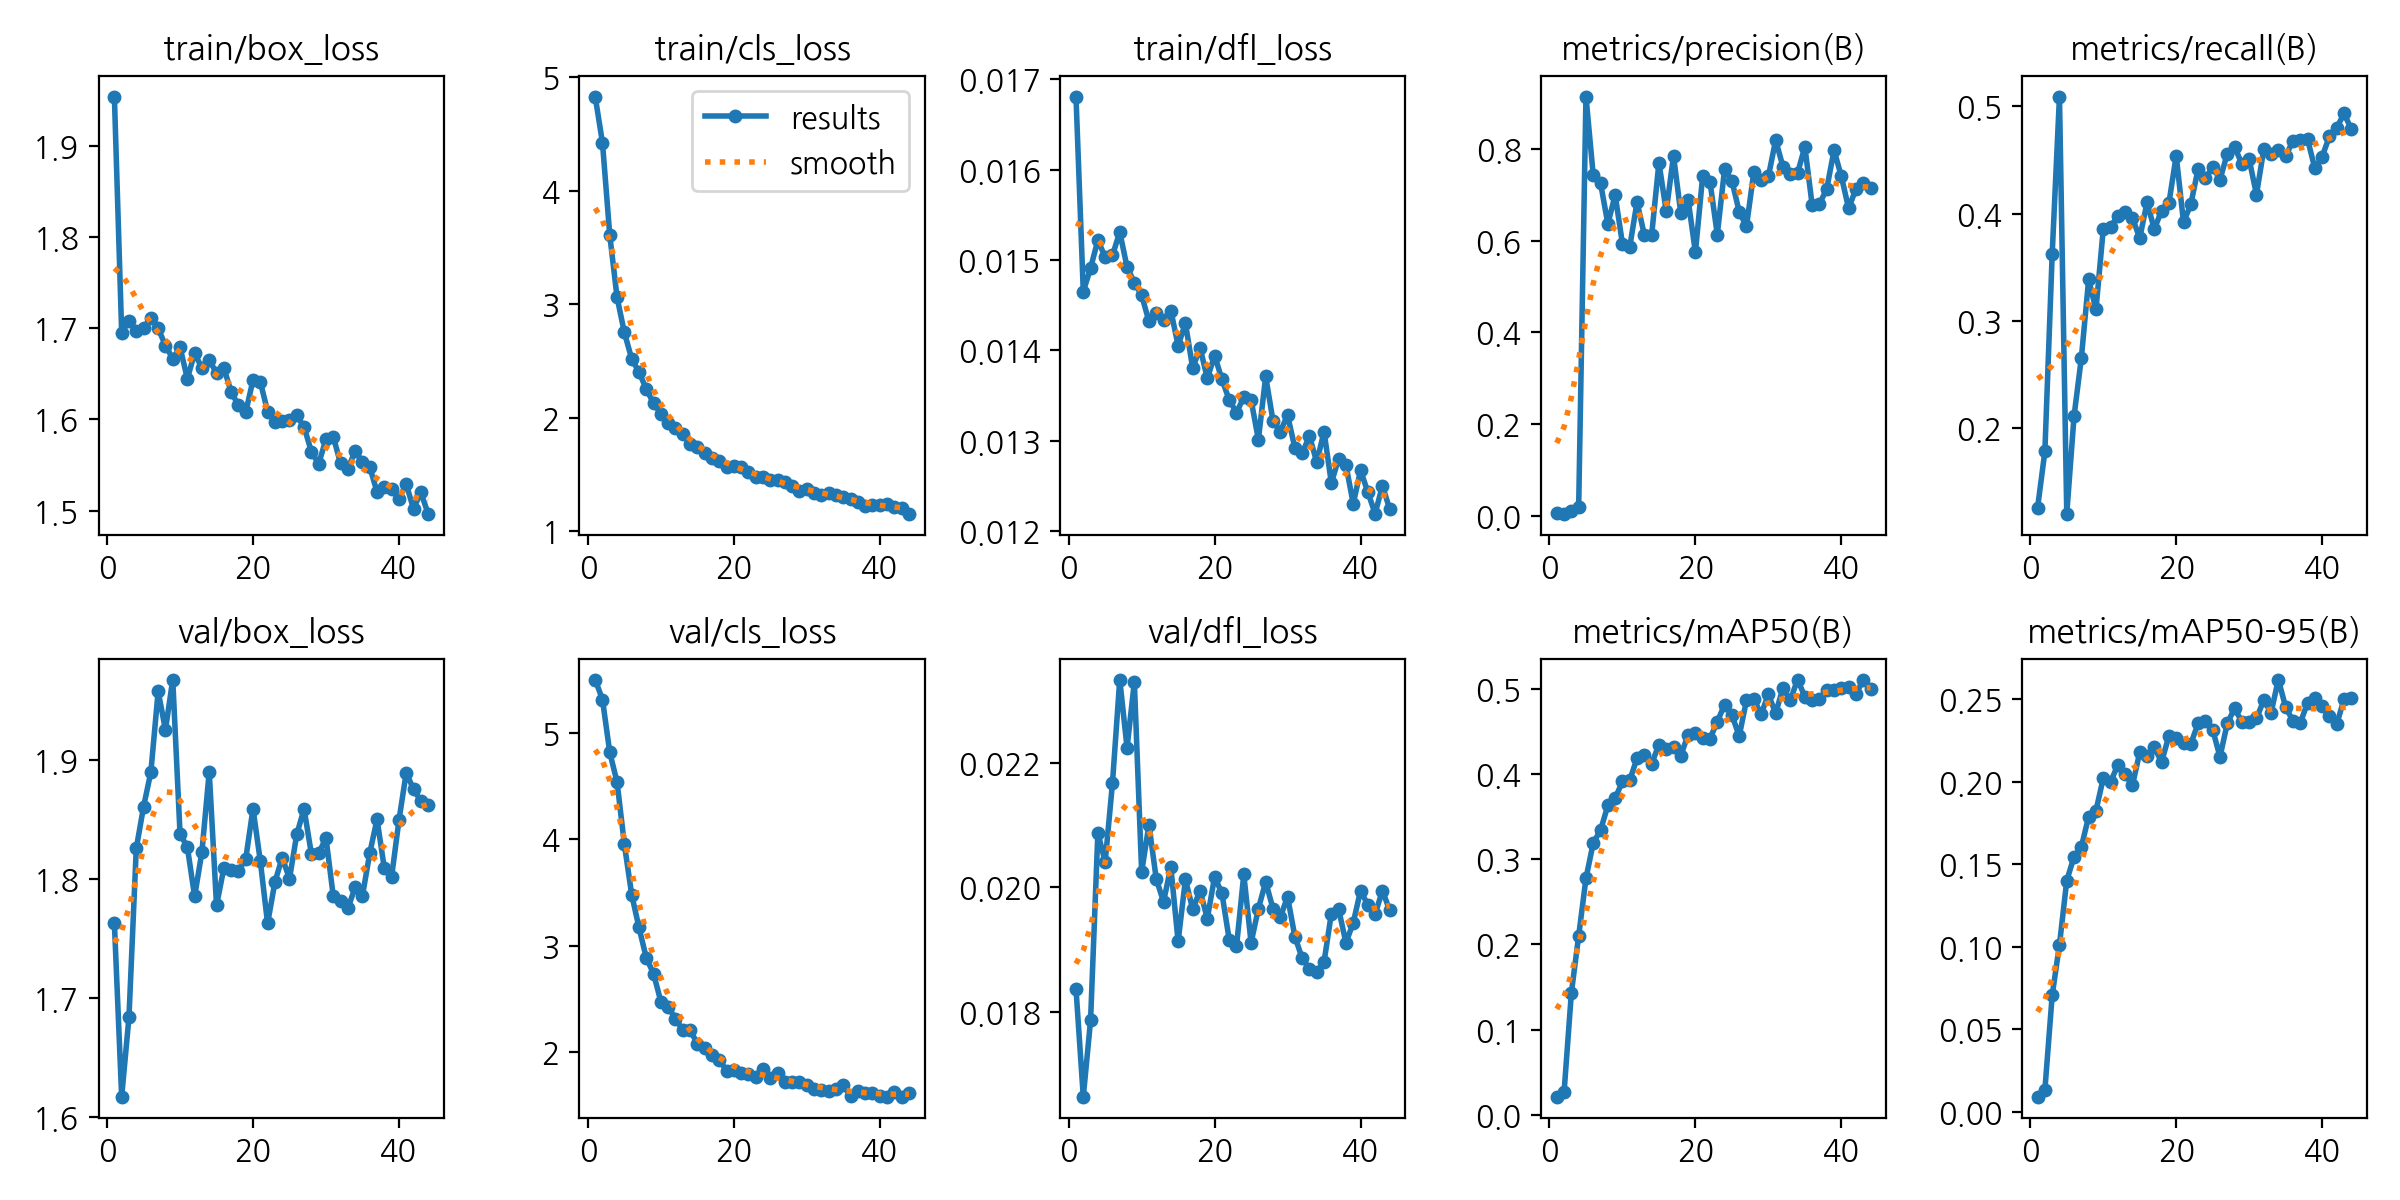

In [6]:
# 훈련/검증 손실 및 mAP 그래프
results_png_path = "runs/detect/03/results.png"
display(Image(results_png_path))

혼동 행렬  
- 정답, 오답, 못찾음(background)의 비율

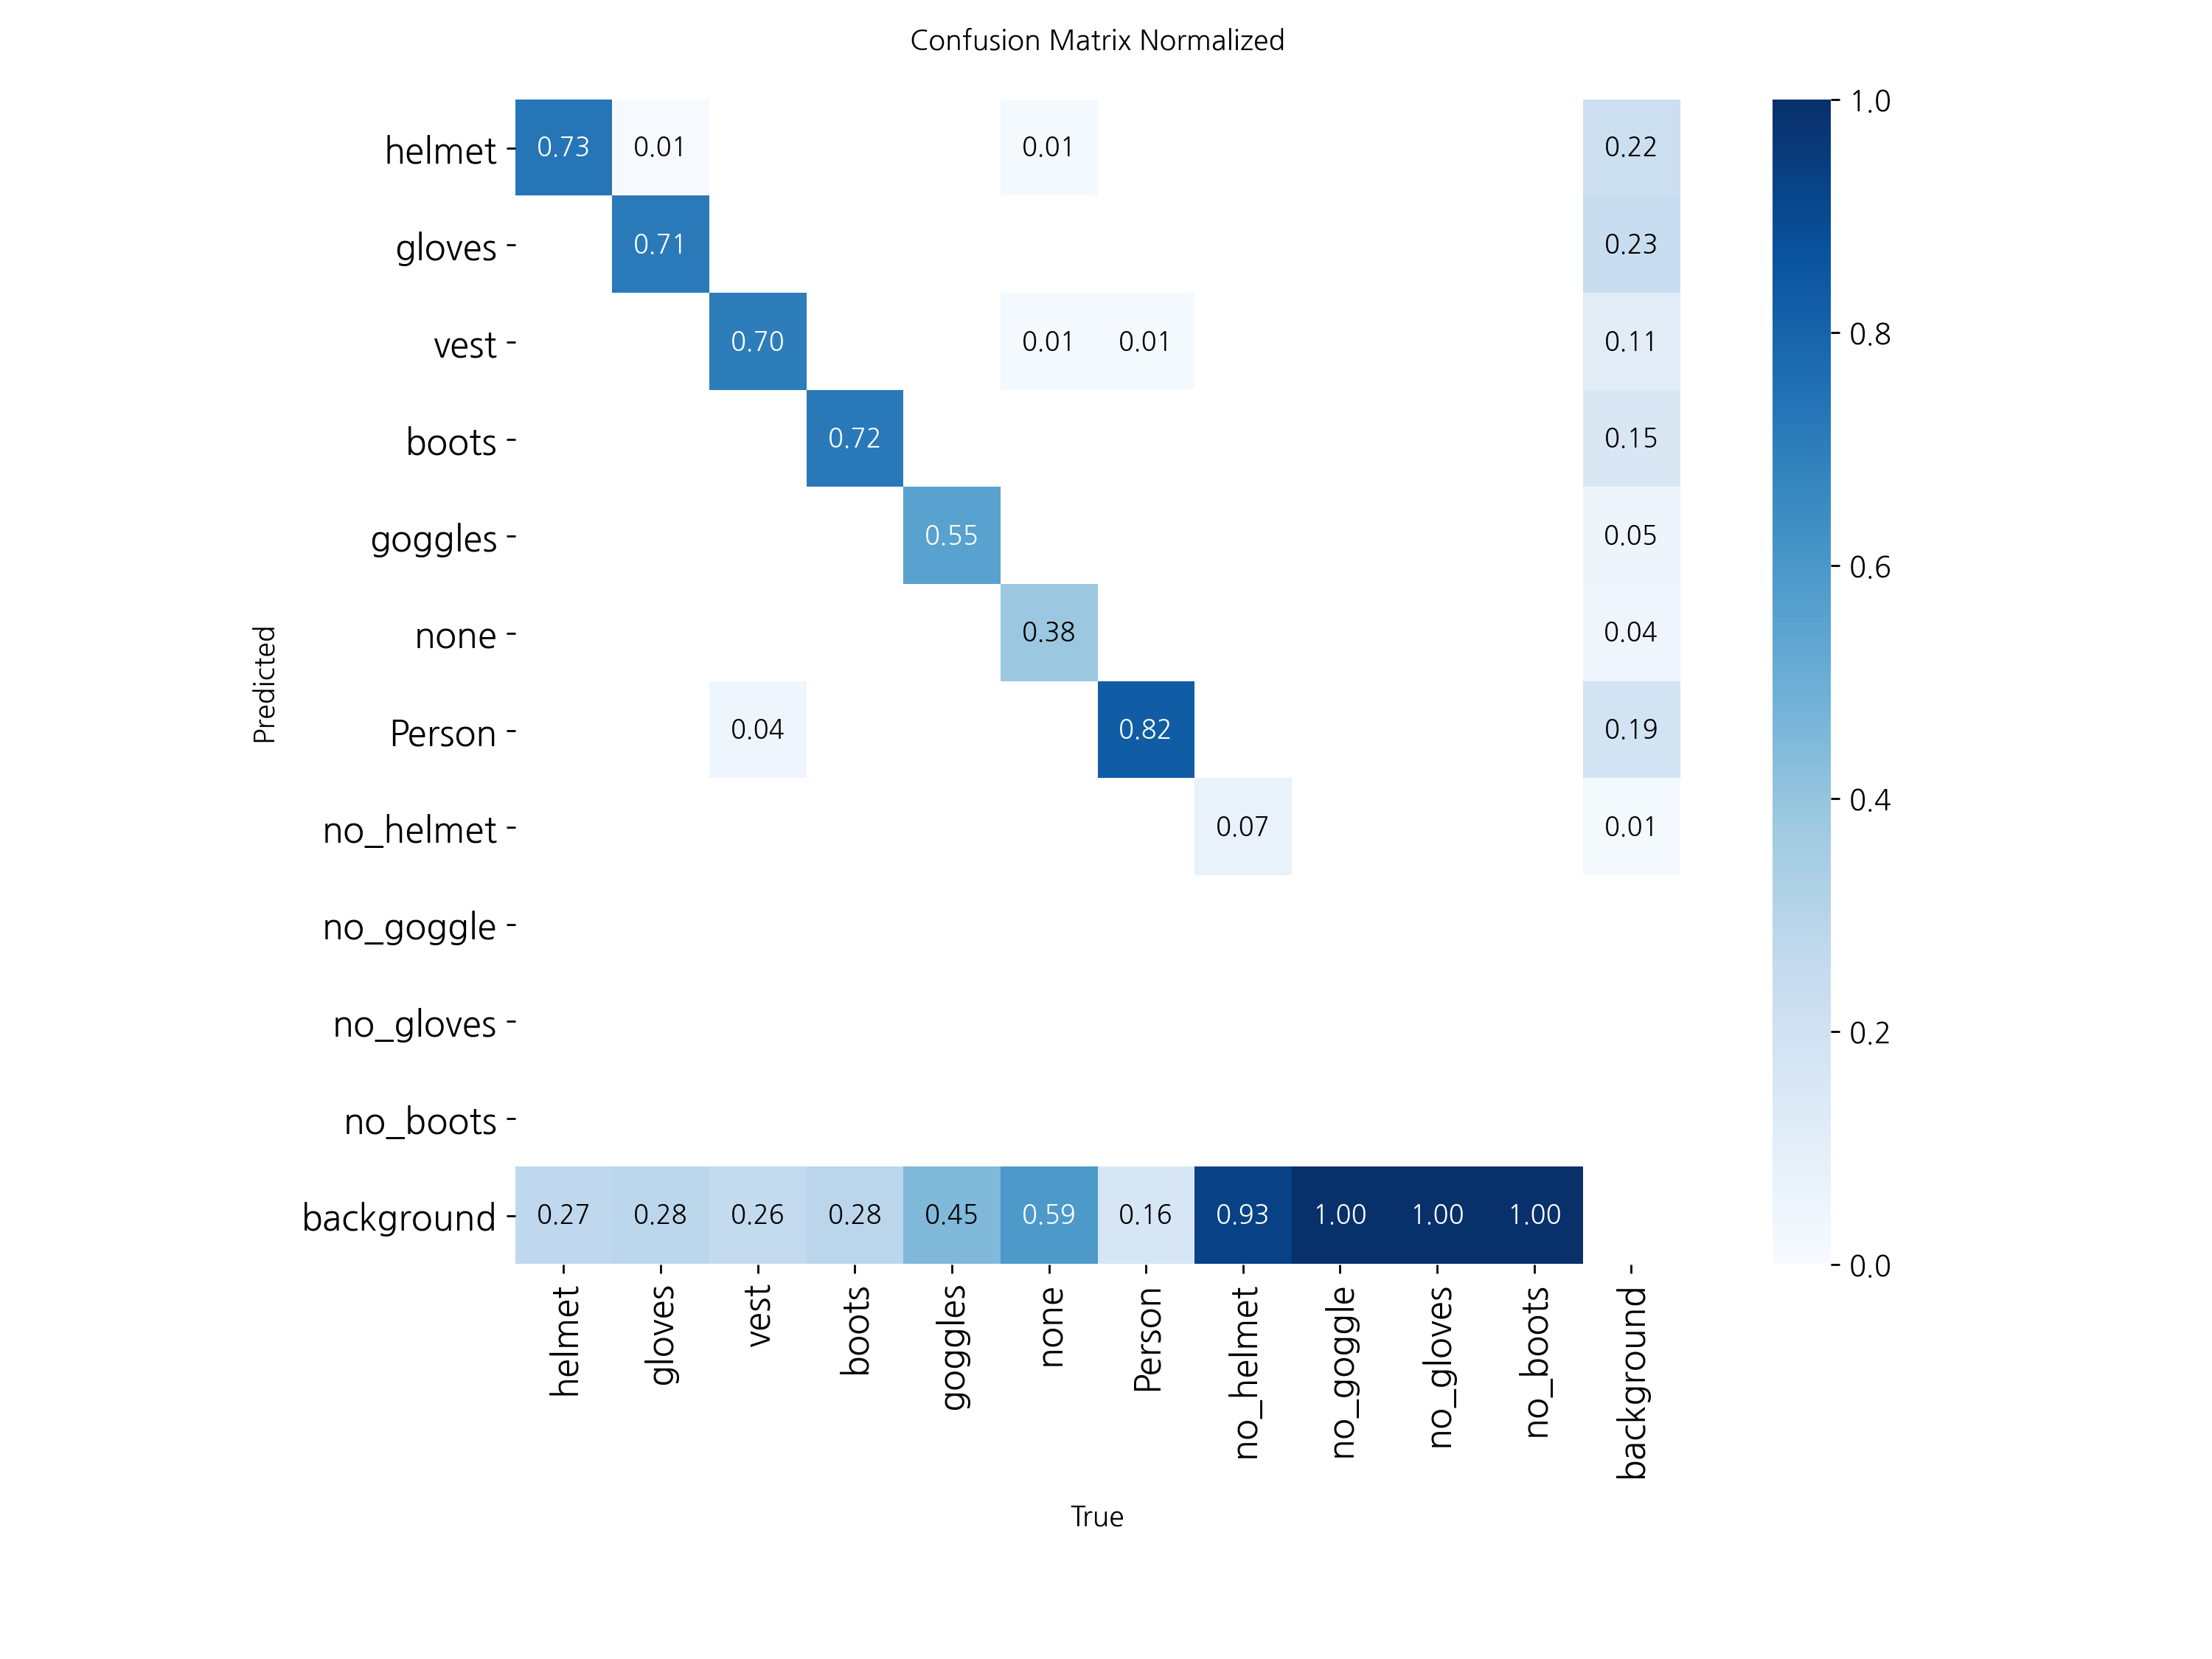

In [7]:
# Confusion Matrix 확인
confusion_matrix_png_path = "runs/detect/03/confusion_matrix_normalized.png"
display(Image(confusion_matrix_png_path))

모델 평가

In [8]:
# 최적 가중치(best.pt) 로드
best_model = YOLO("runs/detect/03/weights/best.pt")

# 평가하기
test_results = best_model.val(
    data=f"{DATASET_PATH}/data.yaml",
    split="test",
    project="03",  # 상위 폴더
    name="test",   # 생성할 폴더
    exist_ok=True,
    verbose=False,
)

print(f"\nmAP50    : {test_results.box.map50:.4f}")
print(f"mAP50-95 : {test_results.box.map:.4f}")
print(f"Precision: {test_results.box.mp:.4f}")
print(f"Recall   : {test_results.box.mr:.4f}")

val: Scanning /datasets/construction-ppe/labels/test... 141 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 141/141 1.5Kit/s 0.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 4.0it/s 2.2s

mAP50    : 0.4648
mAP50-95 : 0.2365
Precision: 0.7596
Recall   : 0.4260
